Nombre: Emilio Rico Hernández
Clase: 8
Challenge: Forecasting Tournament
Fecha: 2026-09-25

# Challenge 8 — Forecasting Tournament

La empresa pregunta: **¿qué método usaríamos para pronosticar las ventas de los próximos meses?** Hago un torneo de modelos con una separación temporal: los últimos 12 meses (2025) son el test y no se usan para entrenar.

Uso las ventas mensuales de `ventas_2.csv` (enero 2023 a diciembre 2025, 36 meses). Como no tenía `statsmodels`, escribí a mano Holt y Holt-Winters, y el bonus es un AR(1) por mínimos cuadrados, que no es un ARIMA completo.

## Paso 1 — Train / Test temporal

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

ventas = pd.read_csv("ventas_2.csv", parse_dates=["fecha"])
serie = ventas.set_index("fecha")["total"].resample("MS").sum()    # ventas de cada mes
print(len(serie), "meses:", serie.index.min().date(), "a", serie.index.max().date())
print(serie.groupby(serie.index.year).mean().round(0))            # promedio mensual por año

# los últimos 12 meses son el test (sin split aleatorio)
train, test = serie.iloc[:-12], serie.iloc[-12:]
print("Train:", train.index.min().date(), "a", train.index.max().date(), "|", len(train), "meses")
print("Test: ", test.index.min().date(), "a", test.index.max().date(), "|", len(test), "meses")
y, y_test = train.values, test.values

36 meses: 2023-01-01 a 2025-12-01
fecha
2023    1759481.0
2024    1736866.0
2025    1668992.0
Name: total, dtype: float64
Train: 2023-01-01 a 2024-12-01 | 24 meses
Test:  2025-01-01 a 2025-12-01 | 12 meses


El train va de enero 2023 a diciembre 2024 (24 meses) y el test de enero a diciembre 2025 (12 meses), en orden cronológico. El nivel casi no cambia: el promedio mensual pasó de $1,759,481 (2023) a $1,736,866 (2024) y $1,668,992 (2025), una baja de ~5% en dos años, sin una tendencia marcada.

## Paso 2 — Modelos

In [2]:
pron = {}
pron["Naive"] = np.repeat(y[-1], 12)      # repite el último valor del train
pron["Seasonal Naive"] = y[-12:]          # repite los 12 meses del último año

def suavizado(y, a, b, g, m, h=12):
    # nivel + tendencia + estacionalidad aditiva de periodo m (con m=1 y g=0 es Holt)
    # devuelve la suma de errores al cuadrado a un paso y el pronóstico de h meses
    nivel, tend = y[:m].mean(), (y[m:2 * m].mean() - y[:m].mean()) / m
    est = list(y[:m] - nivel)
    sse = 0
    for t in range(m, len(y)):
        sse += (y[t] - (nivel + tend + est[t - m])) ** 2
        nuevo = a * (y[t] - est[t - m]) + (1 - a) * (nivel + tend)
        tend = b * (nuevo - nivel) + (1 - b) * tend
        est.append(g * (y[t] - nuevo) + (1 - g) * est[t - m])
        nivel = nuevo
    return sse, np.array([nivel + (i + 1) * tend + est[len(y) - m + i % m] for i in range(h)])

# Holt: busco alfa y beta que minimizan el error en train
r = minimize(lambda p: suavizado(y, p[0], p[1], 0, 1)[0], [0.3, 0.1], bounds=[(0.01, 0.99)] * 2)
pron["Holt"] = suavizado(y, r.x[0], r.x[1], 0, 1)[1]
print("Holt: alfa = %.2f, beta = %.2f" % (r.x[0], r.x[1]))

# Holt-Winters: con solo 24 meses gamma no se puede ajustar (no cambia el error de train), lo fijo en 0.3
r = minimize(lambda p: suavizado(y, p[0], p[1], 0.3, 12)[0], [0.3, 0.1], bounds=[(0.01, 0.99)] * 2)
pron["Holt-Winters"] = suavizado(y, r.x[0], r.x[1], 0.3, 12)[1]
print("Holt-Winters: alfa = %.2f, beta = %.2f, gamma = 0.30" % (r.x[0], r.x[1]))

# Bonus: AR(1), y_t = c + phi * y_(t-1), por mínimos cuadrados
X = np.column_stack([np.ones(len(y) - 1), y[:-1]])
c, phi = np.linalg.lstsq(X, y[1:], rcond=None)[0]
ultimo, ar = y[-1], []
for i in range(12):
    ultimo = c + phi * ultimo
    ar.append(ultimo)
pron["AR(1) (bonus)"] = np.array(ar)
print("AR(1): phi = %.2f" % phi)

Holt: alfa = 0.30, beta = 0.49
Holt-Winters: alfa = 0.35, beta = 0.01, gamma = 0.30
AR(1): phi = -0.13


## Paso 3 y 4 — Evaluación y tabla de métricas

In [3]:
filas = []
for nombre, p in pron.items():
    e = y_test - p
    filas.append([nombre, np.abs(e).mean(), np.sqrt((e ** 2).mean()), (np.abs(e) / y_test).mean() * 100])
tabla = pd.DataFrame(filas, columns=["Modelo", "MAE", "RMSE", "MAPE (%)"]).set_index("Modelo").sort_values("MAE")
print(tabla.round(1))

ganador = tabla["MAE"].idxmin()
print("\nMenor MAE:", ganador, "| menor RMSE:", tabla["RMSE"].idxmin())
print("Ventas promedio del test: $%s" % format(y_test.mean(), ",.0f"))

                     MAE      RMSE  MAPE (%)
Modelo                                      
Naive           117487.5  159334.0       7.6
AR(1) (bonus)   124811.3  171456.0       8.1
Seasonal Naive  169414.4  191946.4      10.3
Holt-Winters    190884.4  248547.1      11.3
Holt            232919.0  278142.5      13.5

Menor MAE: Naive | menor RMSE: Naive
Ventas promedio del test: $1,668,992


El **Naive** tuvo el menor MAE ($117,488) y también el menor RMSE ($159,334), con un MAPE de 7.6%. Le siguen el AR(1) ($124,811 de MAE) y, más atrás, Seasonal Naive ($169,414), Holt-Winters ($190,884) y Holt ($232,919). Los modelos que intentan capturar tendencia o estacionalidad empeoraron el pronóstico. El error del Naive equivale a ~7% de las ventas mensuales promedio del test ($1,668,992).

El AR(1) quedó a solo 6% del Naive en MAE y su φ = -0.13 es casi cero: la serie se parece a ruido alrededor de un nivel fijo. En Holt-Winters, β quedó en el mínimo permitido (0.01): casi no actualiza la tendencia.

## Paso 5 — Visualización

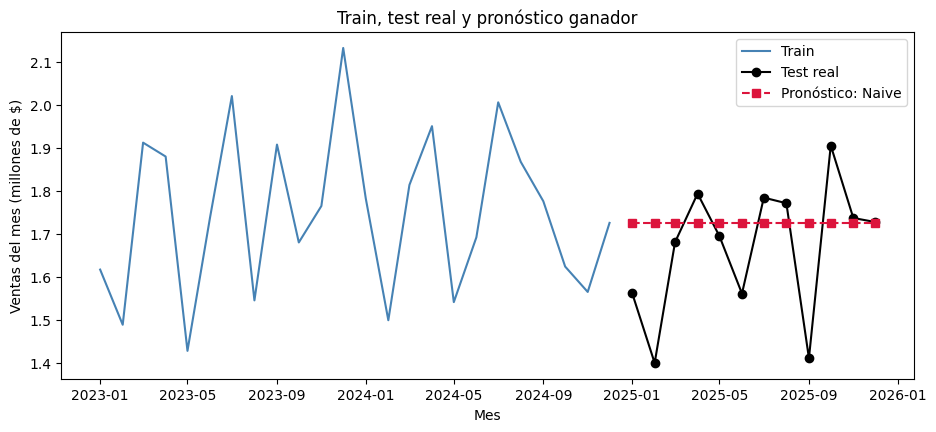

In [4]:
plt.figure(figsize=(11, 4.5))
plt.plot(train.index, train / 1e6, color="steelblue", label="Train")
plt.plot(test.index, test / 1e6, color="black", marker="o", label="Test real")
plt.plot(test.index, pron[ganador] / 1e6, color="crimson", linestyle="--", marker="s", label="Pronóstico: " + ganador)
plt.title("Train, test real y pronóstico ganador")
plt.xlabel("Mes")
plt.ylabel("Ventas del mes (millones de $)")
plt.legend()
plt.show()

El pronóstico ganador es una línea horizontal en $1.73 M, el valor de diciembre de 2024. Las ventas reales oscilan alrededor de ella: quedan por debajo sobre todo en febrero, junio y septiembre, y por encima en abril, julio, agosto y octubre. El Naive no captura ningún vaivén, pero tampoco se equivoca mucho de forma sistemática, y por eso gana. Los modelos con tendencia o estacionalidad parecen proyectar un patrón de 2023-2024 que en 2025 no se repitió.

## Paso 6 — Residuos del modelo ganador

Real promedio: 1,668,992 | pronóstico promedio: 1,725,506
Error medio: -56514 | meses que subestima: 6 | sobreestima: 6
Autocorrelación lag 1 de los residuos: -0.16
fecha
2025-01-01   -163.0
2025-02-01   -326.0
2025-03-01    -45.0
2025-04-01     68.0
2025-05-01    -31.0
2025-06-01   -164.0
2025-07-01     59.0
2025-08-01     46.0
2025-09-01   -315.0
2025-10-01    180.0
2025-11-01     11.0
2025-12-01      2.0
Freq: MS


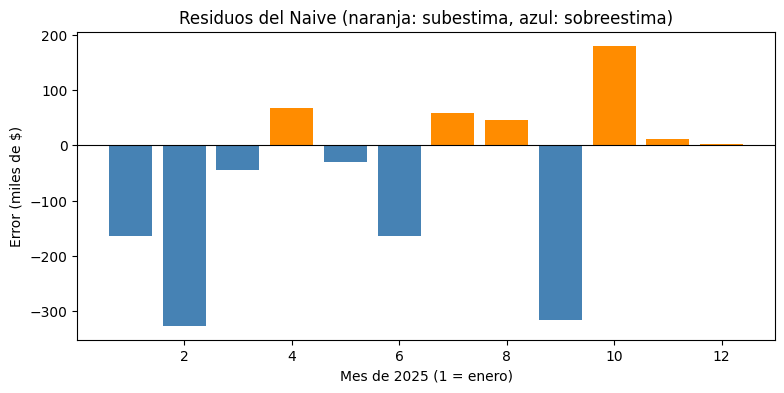

In [5]:
res = pd.Series(y_test - pron[ganador], index=test.index)      # e_t = real - pronóstico
print("Real promedio: %s | pronóstico promedio: %s" % (format(y_test.mean(), ",.0f"), format(pron[ganador].mean(), ",.0f")))
print("Error medio:", round(res.mean()), "| meses que subestima:", (res > 0).sum(), "| sobreestima:", (res < 0).sum())
print("Autocorrelación lag 1 de los residuos:", round(res.autocorr(lag=1), 2))
print((res / 1e3).round(0).to_string())

plt.figure(figsize=(9, 4))
plt.bar(res.index.month, res / 1e3, color=["darkorange" if v > 0 else "steelblue" for v in res])
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Residuos del " + ganador + " (naranja: subestima, azul: sobreestima)")
plt.xlabel("Mes de 2025 (1 = enero)")
plt.ylabel("Error (miles de $)")
plt.show()

**Sesgo:** el error medio es -$56,514, así que en promedio **sobreestima** (pronóstico promedio de $1,725,506 contra $1,668,992 reales, ~3%), porque diciembre de 2024 quedó por encima del nivel de 2025. Subestima en 6 meses y sobreestima en 6, pero las sobreestimaciones son más grandes.

**Mayores errores:** febrero (-$326 mil), septiembre (-$315 mil) y octubre (+$180 mil).

**Patrón:** la autocorrelación de los residuos en lag 1 es -0.16, débil, y no hay rachas largas. Solo se nota que de enero a junio se sobreestima en 5 de 6 meses y de julio a diciembre solo septiembre se sobreestima, como si las ventas se recuperaran en la segunda mitad de 2025. Con 12 puntos no puedo asegurar que sea un patrón real.

## Preguntas de reflexión

1. **¿Cuál modelo tuvo menor MAE?** El Naive, con $117,488.
2. **¿Cuál tuvo menor RMSE?** También el Naive, con $159,334.
3. **¿Son el mismo?** Sí. Pueden diferir cuando un modelo evita errores muy grandes (el RMSE los penaliza más), pero aquí el Naive ganó en las dos.
4. **¿Seasonal Naive fue competitivo?** No. Su MAE ($169,414) es 44% mayor que el del Naive. Repetir el mismo mes del año pasado solo sirve si el patrón mensual se repite, y aquí no fue así.
5. **¿El modelo más complejo fue el mejor?** No. Holt y Holt-Winters, los de más parámetros, quedaron en los últimos lugares: con 24 meses de train no hay información suficiente para estimar bien tendencia y estacionalidad.
6. **¿Qué modelo usaría en producción?** Ver la recomendación.

## Recomendación

El ganador del torneo es el Naive (MAE $117,488, RMSE $159,334, MAPE 7.6%), pero el ranking es frágil: el test tiene solo 12 meses, hay un único punto de corte, el AR(1) quedó a 6% de diferencia y el Naive ganó en parte porque diciembre de 2024 quedó cerca del nivel de 2025. Con 36 meses de historia, la estacionalidad no se puede aprender bien y aquí no ayudó.

Recomiendo un modelo simple como línea base: el Naive, o el AR(1), que casi empata y depende menos de un solo mes. Esperaría un error de ~$120 mil al mes (7% a 8% de las ventas). Solo probaría Holt-Winters con 4 o 5 años de historia y validándolo con varios cortes en el tiempo, no con uno.